=== CO Level Prediction using LSTM Model ===

1. Loading and preparing data...
Original data shape: (5430, 6)
Columns: ['id', 'lat', 'long', 'zone', 'date', 'CO']

Date range: 2023-11-01 00:00:00 to 2024-04-29 00:00:00
Number of sensors: 30
Total days: 181

Missing values:
id         0
lat        0
long       0
zone       0
date       0
CO      1369
dtype: int64

Handling missing values with time interpolation...
Daily average data shape: (181, 2)
CO statistics - Mean: 0.047385, Std: 0.013713

2. Exploratory Data Analysis...


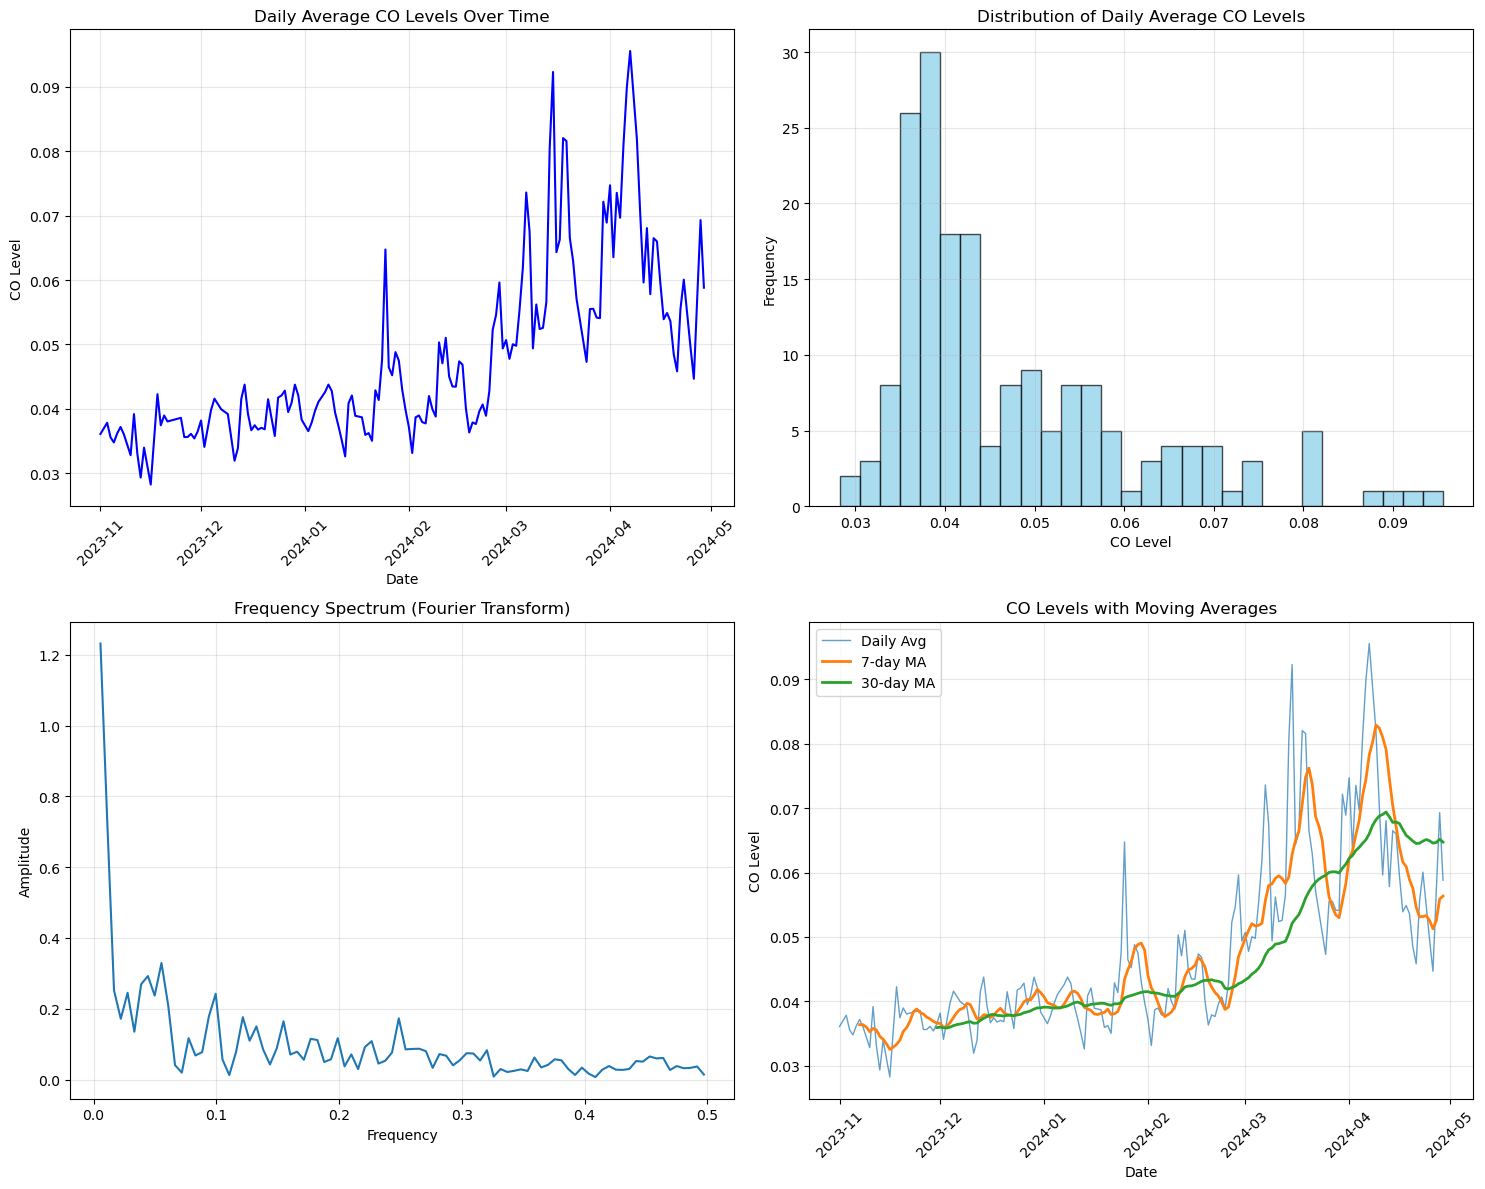


3. Preparing data for LSTM model...
Sequence shape: X=(151, 30), y=(151,)
Training set: X_train=(120, 30, 1), y_train=(120,)
Test set: X_test=(31, 30, 1), y_test=(31,)

4. Creating and training LSTM model...
Model architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training the model...
Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0381 - mae: 0.1441 - val_loss: 0.0565 - val_mae: 0.2056 - learning_rate: 0.0010
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0174 - mae: 0.0946 - val_loss: 0.0500 - val_mae: 0.1700 - learning_rate: 0.0010
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0189 - mae: 0.0904 - val_loss: 0.0349 - val_mae: 0.1621 - learning_rate: 0.0010
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0150 - mae: 0.0890 - val_loss: 0.0348 - val_mae: 0.1502 - learning_rate: 0.0010
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0147 - mae: 0.0791 - val_loss: 0.0340 - val_mae: 0.1501 - learning_rate: 0.0010
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0151 - mae: 0.0854 - val_loss: 0.0323 - val_mae: 0.1514 - learning_rate: 0.0010
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0131 - mae: 0.0743 - val_loss: 0.0320 - val_mae: 0.1490 - learning_rate: 0.00

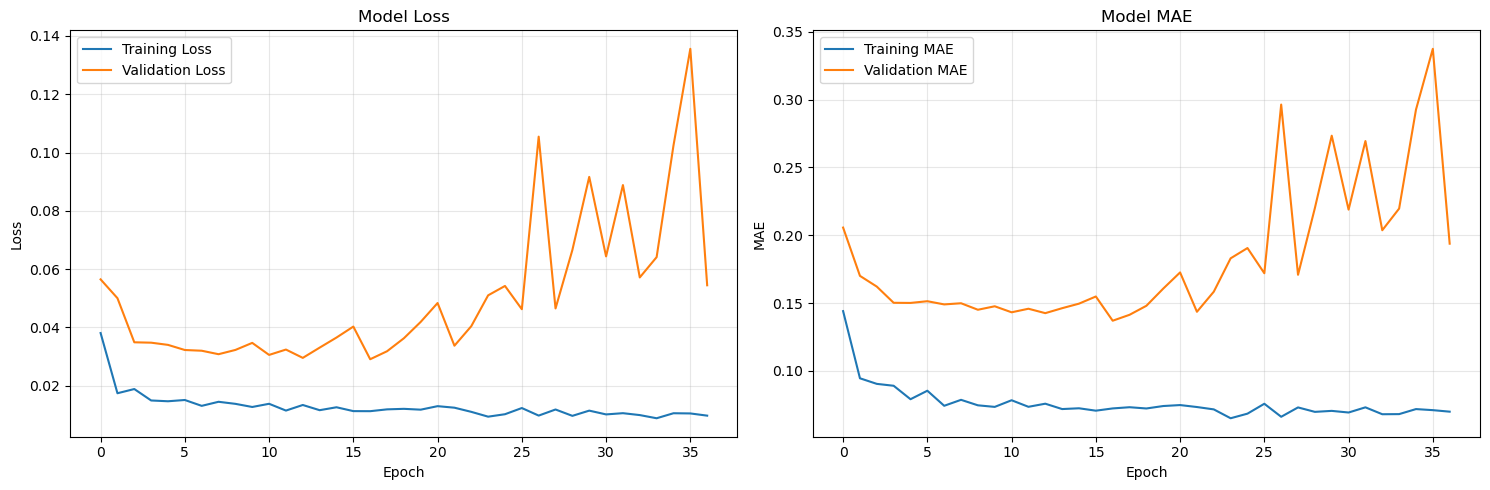


5. Evaluating model performance...

Model Performance Metrics:
RMSE: 0.011491
MAE: 0.009226
R²: 0.189941


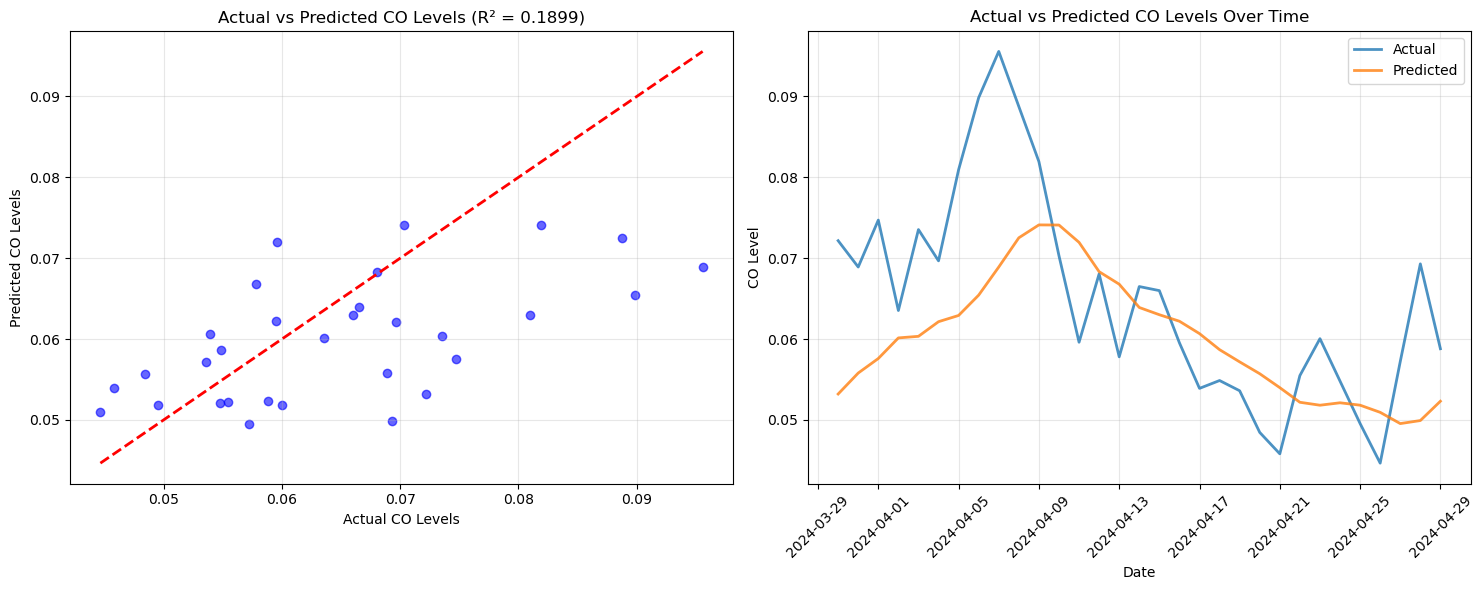


6. Forecasting CO levels for next 7 days...



7-Day CO Level Forecast:
      Date  Predicted_CO
2024-04-30      0.053004
2024-05-01      0.052622
2024-05-02      0.052161
2024-05-03      0.051680
2024-05-04      0.051237
2024-05-05      0.050877
2024-05-06      0.050649

Model saved as 'co_lstm_model.h5'

7. Model implementation example...

Creating sample data for prediction...


ValueError: Could not deserialize 'keras.metrics.mse' because it is not a KerasSaveable subclass

In [2]:
# CO Level Prediction using LSTM Model
# Complete implementation following the specified requirements

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from scipy.fft import fft, fftfreq
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("=== CO Level Prediction using LSTM Model ===\n")

# ==========================================
# 1. การเตรียมข้อมูล (Data Preparation)
# ==========================================

print("1. Loading and preparing data...")

# Load data
df = pd.read_csv('CO_hex30_urban.csv')
print(f"Original data shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Sort by sensor ID and date
df = df.sort_values(['id', 'date']).reset_index(drop=True)

# Display data info
print(f"\nDate range: {df['date'].min()} to {df['date'].max()}")
print(f"Number of sensors: {df['id'].nunique()}")
print(f"Total days: {df['date'].nunique()}")

# Check for missing values
print(f"\nMissing values:\n{df.isnull().sum()}")

# Handle missing values using time interpolation for each sensor
print("\nHandling missing values with time interpolation...")
df_interpolated = df.groupby('id').apply(lambda x: x.set_index('date').interpolate(method='time').reset_index()).reset_index(drop=True)

# Calculate daily average CO levels across all sensors
daily_avg = df_interpolated.groupby('date')['CO'].mean().reset_index()
daily_avg.columns = ['date', 'avg_CO']

print(f"Daily average data shape: {daily_avg.shape}")
print(f"CO statistics - Mean: {daily_avg['avg_CO'].mean():.6f}, Std: {daily_avg['avg_CO'].std():.6f}")

# ==========================================
# 2. การวิเคราะห์ข้อมูลเบื้องต้น (Exploratory Data Analysis)
# ==========================================

print("\n2. Exploratory Data Analysis...")

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Daily CO levels time series
axes[0, 0].plot(daily_avg['date'], daily_avg['avg_CO'], linewidth=1.5, color='blue')
axes[0, 0].set_title('Daily Average CO Levels Over Time')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('CO Level')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# Histogram of CO values
axes[0, 1].hist(daily_avg['avg_CO'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 1].set_title('Distribution of Daily Average CO Levels')
axes[0, 1].set_xlabel('CO Level')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# Fourier Transform for trend analysis
co_values = daily_avg['avg_CO'].values
n = len(co_values)
fft_values = fft(co_values - np.mean(co_values))
frequencies = fftfreq(n, d=1.0)

# Plot frequency spectrum
positive_freq_idx = frequencies > 0
axes[1, 0].plot(frequencies[positive_freq_idx], np.abs(fft_values[positive_freq_idx]))
axes[1, 0].set_title('Frequency Spectrum (Fourier Transform)')
axes[1, 0].set_xlabel('Frequency')
axes[1, 0].set_ylabel('Amplitude')
axes[1, 0].grid(True, alpha=0.3)

# Moving averages for trend analysis
daily_avg['MA_7'] = daily_avg['avg_CO'].rolling(window=7).mean()
daily_avg['MA_30'] = daily_avg['avg_CO'].rolling(window=30).mean()

axes[1, 1].plot(daily_avg['date'], daily_avg['avg_CO'], label='Daily Avg', alpha=0.7, linewidth=1)
axes[1, 1].plot(daily_avg['date'], daily_avg['MA_7'], label='7-day MA', linewidth=2)
axes[1, 1].plot(daily_avg['date'], daily_avg['MA_30'], label='30-day MA', linewidth=2)
axes[1, 1].set_title('CO Levels with Moving Averages')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('CO Level')
axes[1, 1].legend()
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# 3. การเตรียมข้อมูลสำหรับแบบจำลอง (Data Preparation for Model)
# ==========================================

print("\n3. Preparing data for LSTM model...")

def create_sequences(data, sequence_length):
    """Create sequences for LSTM training"""
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:(i + sequence_length)])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)

# Use daily average CO values for modeling
co_data = daily_avg['avg_CO'].values.reshape(-1, 1)

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(co_data)

# Create sequences
sequence_length = 30  # Use 30 days to predict next day
X, y = create_sequences(scaled_data.flatten(), sequence_length)

print(f"Sequence shape: X={X.shape}, y={y.shape}")

# Split data (80% train, 20% test)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape for LSTM (samples, time steps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"Training set: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set: X_test={X_test.shape}, y_test={y_test.shape}")

# ==========================================
# 4. การสร้างและฝึกแบบจำลอง (Model Creation and Training)
# ==========================================

print("\n4. Creating and training LSTM model...")

# Build bidirectional LSTM model
model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True, input_shape=(sequence_length, 1))),
    Dropout(0.2),
    Bidirectional(LSTM(32, return_sequences=False)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

# Compile model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

print("Model architecture:")
model.summary()

# Define callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-7,
    verbose=1
)

# Train the model
print("\nTraining the model...")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history.history['loss'], label='Training Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_title('Model Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['mae'], label='Training MAE')
ax2.plot(history.history['val_mae'], label='Validation MAE')
ax2.set_title('Model MAE')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# 5. การประเมินแบบจำลอง (Model Evaluation)
# ==========================================

print("\n5. Evaluating model performance...")

# Make predictions on test set
y_pred_scaled = model.predict(X_test, verbose=0)

# Inverse transform to get actual values
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_actual = scaler.inverse_transform(y_pred_scaled).flatten()

# Calculate performance metrics
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"\nModel Performance Metrics:")
print(f"RMSE: {rmse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"R²: {r2:.6f}")

# Create prediction visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Actual vs Predicted plot
ax1.scatter(y_test_actual, y_pred_actual, alpha=0.6, color='blue')
ax1.plot([y_test_actual.min(), y_test_actual.max()], 
         [y_test_actual.min(), y_test_actual.max()], 'r--', lw=2)
ax1.set_xlabel('Actual CO Levels')
ax1.set_ylabel('Predicted CO Levels')
ax1.set_title(f'Actual vs Predicted CO Levels (R² = {r2:.4f})')
ax1.grid(True, alpha=0.3)

# Time series comparison
test_dates = daily_avg['date'].iloc[train_size + sequence_length:].values
ax2.plot(test_dates, y_test_actual, label='Actual', linewidth=2, alpha=0.8)
ax2.plot(test_dates, y_pred_actual, label='Predicted', linewidth=2, alpha=0.8)
ax2.set_xlabel('Date')
ax2.set_ylabel('CO Level')
ax2.set_title('Actual vs Predicted CO Levels Over Time')
ax2.legend()
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# 6. การพยากรณ์ (Forecasting)
# ==========================================

print("\n6. Forecasting CO levels for next 7 days...")

# Prepare data for forecasting
last_sequence = scaled_data[-sequence_length:].reshape(1, sequence_length, 1)

# Forecast next 7 days
forecast_scaled = []
current_sequence = last_sequence.copy()

for i in range(7):
    next_pred = model.predict(current_sequence, verbose=0)[0, 0]
    forecast_scaled.append(next_pred)
    
    # Update sequence for next prediction
    current_sequence = np.roll(current_sequence, -1, axis=1)
    current_sequence[0, -1, 0] = next_pred

# Inverse transform forecasts
forecast_actual = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1, 1)).flatten()

# Generate forecast dates
last_date = daily_avg['date'].iloc[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7, freq='D')

# Create forecast results
forecast_results = pd.DataFrame({
    'Date': forecast_dates,
    'Predicted_CO': forecast_actual
})

print("\n7-Day CO Level Forecast:")
print(forecast_results.to_string(index=False))

# Save the model
model.save('co_lstm_model.h5')
print("\nModel saved as 'co_lstm_model.h5'")

# ==========================================
# 7. การนำไปใช้ (Implementation)
# ==========================================

print("\n7. Model implementation example...")

# Create sample data for demonstration
print("\nCreating sample data for prediction...")

# Load the saved model
loaded_model = load_model('co_lstm_model.h5')
print("Model loaded successfully!")

# Use the last 30 days of actual data as input
sample_input = scaled_data[-30:].reshape(1, 30, 1)

# Make prediction for next 7 days using loaded model
sample_forecast = []
current_seq = sample_input.copy()

for i in range(7):
    pred = loaded_model.predict(current_seq, verbose=0)[0, 0]
    sample_forecast.append(pred)
    current_seq = np.roll(current_seq, -1, axis=1)
    current_seq[0, -1, 0] = pred

# Convert to actual values
sample_forecast_actual = scaler.inverse_transform(np.array(sample_forecast).reshape(-1, 1)).flatten()

# ==========================================
# 8. การแสดงผลรายงาน (Results Report)
# ==========================================

print("\n8. Final Results Report")
print("=" * 50)

# Historical data summary
print(f"\nHistorical Data Summary:")
print(f"- Time period: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
print(f"- Total sensors: {df['id'].nunique()}")
print(f"- Total observations: {len(df)}")
print(f"- Average CO level: {daily_avg['avg_CO'].mean():.6f}")

# Model performance summary
print(f"\nModel Performance:")
print(f"- RMSE: {rmse:.6f}")
print(f"- MAE: {mae:.6f}")
print(f"- R² Score: {r2:.6f}")

# Forecast summary
print(f"\nForecast Summary (Next 7 Days):")
for i, (date, co_level) in enumerate(zip(forecast_dates, forecast_actual)):
    print(f"Day {i+1} ({date.strftime('%Y-%m-%d')}): {co_level:.6f}")

print(f"\nForecast Statistics:")
print(f"- Mean predicted CO: {np.mean(forecast_actual):.6f}")
print(f"- Min predicted CO: {np.min(forecast_actual):.6f}")
print(f"- Max predicted CO: {np.max(forecast_actual):.6f}")

# Final visualization
plt.figure(figsize=(15, 8))

# Plot historical data
historical_dates = daily_avg['date'].iloc[-60:].values  # Last 60 days
historical_co = daily_avg['avg_CO'].iloc[-60:].values

plt.plot(historical_dates, historical_co, 'b-', linewidth=2, label='Historical Data', alpha=0.8)

# Plot forecast
forecast_dates_full = pd.concat([
    pd.Series([daily_avg['date'].iloc[-1]]),
    pd.Series(forecast_dates)
]).values

forecast_co_full = np.concatenate([
    [daily_avg['avg_CO'].iloc[-1]],
    forecast_actual
])

plt.plot(forecast_dates_full, forecast_co_full, 'r--', linewidth=3, label='7-Day Forecast', marker='o', markersize=6)

# Add confidence interval (simple approach)
forecast_std = np.std(y_test_actual - y_pred_actual)
upper_bound = forecast_actual + 1.96 * forecast_std
lower_bound = forecast_actual - 1.96 * forecast_std

plt.fill_between(forecast_dates, lower_bound, upper_bound, alpha=0.2, color='red', label='95% Confidence Interval')

plt.axvline(x=daily_avg['date'].iloc[-1], color='gray', linestyle=':', alpha=0.7, label='Forecast Start')
plt.xlabel('Date', fontsize=12)
plt.ylabel('CO Level', fontsize=12)
plt.title('CO Level Prediction: Historical Data and 7-Day Forecast', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("CO Level Prediction Analysis Complete!")
print("Model and forecasts are ready for use.")
print("=" * 50)